# 📈 Statistical Analysis

## Objective

The objective of this notebook is to statistically analyze engine operational data and identify patterns that support maintenance planning and operational decision-making.

The analysis includes:

- Descriptive Statistics
- Correlation Analysis
- Distribution Analysis
- Engine Status Comparison
- Business Interpretation

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
df = pd.read_csv("../data/processed/aeroengine_feature_engineered.csv")
df.head()

,Engine_ID,Cycle,Operational_Setting_1,Operational_Setting_2,Sensor_2,Sensor_3,Sensor_4,Sensor_6,Sensor_7,Sensor_8,...,Sensor_14,Sensor_15,Sensor_17,Sensor_20,Sensor_21,Engine_Life,RUL,Engine_Status,Average_Sensor_Value,Sensor_Variability
0,1,1,-0.0007,-0.0004,641.82,1589.70,1400.60,21.61,554.36,2388.06,...,8138.62,8.4195,392,39.06,23.4190,192,191,Healthy,1813.400567,2875.867171
1,1,2,0.0019,-0.0003,642.15,1591.82,1403.14,21.61,553.75,2388.04,...,8131.49,8.4318,392,39.00,23.4236,192,190,Healthy,1813.117693,2874.319802
2,1,3,-0.0043,0.0003,642.35,1587.99,1404.20,21.61,554.26,2388.08,...,8133.23,8.4178,390,38.95,23.3442,192,189,Healthy,1813.539467,2876.258108
3,1,4,0.0007,0.0000,642.35,1582.79,1401.87,21.61,554.45,2388.11,...,8133.83,8.3682,392,38.88,23.3739,192,188,Healthy,1813.012140,2875.704060
4,1,5,-0.0019,-0.0002,642.37,1582.85,1406.22,21.61,554.00,2388.06,...,8133.80,8.4294,393,38.90,23.4044,192,187,Healthy,1813.686920,2876.660958


In [2]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
Engine_ID,20631.0,51.506568,29.227633,1.000000,26.000000,52.000000,77.000000,100.000000
Cycle,20631.0,108.807862,68.880990,1.000000,52.000000,104.000000,156.000000,362.000000
Operational_Setting_1,20631.0,-0.000009,0.002187,-0.008700,-0.001500,0.000000,0.001500,0.008700
Operational_Setting_2,20631.0,0.000002,0.000293,-0.000600,-0.000200,0.000000,0.000300,0.000600
Sensor_2,20631.0,642.680934,0.500053,641.210000,642.325000,642.640000,643.000000,644.530000
Sensor_3,20631.0,1590.523119,6.131150,1571.040000,1586.260000,1590.100000,1594.380000,1616.910000
Sensor_4,20631.0,1408.933782,9.000605,1382.250000,1402.360000,1408.040000,1414.555000,1441.490000
Sensor_6,20631.0,21.609803,0.001389,21.600000,21.610000,21.610000,21.610000,21.610000
Sensor_7,20631.0,553.367711,0.885092,549.850000,552.810000,553.440000,554.010000,556.060000
Sensor_8,20631.0,2388.096652,0.070985,2387.900000,2388.050000,2388.090000,2388.140000,2388.560000


### Business Insight

The descriptive statistics summarize the operational characteristics of aircraft engines.

Metrics such as mean, standard deviation, minimum, and maximum values help identify the range and variability of operational parameters.

In [3]:
df["Engine_Status"].value_counts()

Engine_Status
Healthy     10531
Critical     5100
Warning      5000
Name: count, dtype: int64

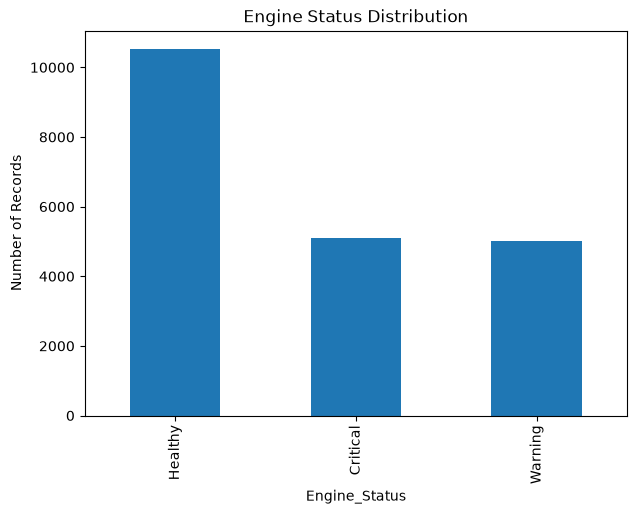

In [4]:
plt.figure(figsize=(7,5))
df["Engine_Status"].value_counts().plot(kind="bar")
plt.title("Engine Status Distribution")
plt.ylabel("Number of Records")
plt.show()

### Business Insight

The distribution of engine health categories helps maintenance teams prioritize inspections and preventive maintenance activities.

In [6]:
corr = df.corr(numeric_only=True)
rul_corr = corr["RUL"].sort_values(ascending=False)
rul_corr

RUL                      1.000000
Sensor_12                0.671983
Sensor_7                 0.657223
Sensor_21                0.635662
Sensor_20                0.629428
Engine_Life              0.363152
Engine_ID                0.078753
Operational_Setting_2   -0.001948
Operational_Setting_1   -0.003198
Sensor_6                -0.128348
Sensor_14               -0.306769
Sensor_Variability      -0.346787
Sensor_9                -0.390102
Average_Sensor_Value    -0.518937
Sensor_13               -0.562569
Sensor_8                -0.563968
Sensor_3                -0.584520
Sensor_17               -0.606154
Sensor_2                -0.606484
Sensor_15               -0.642667
Sensor_4                -0.678948
Sensor_11               -0.696228
Cycle                   -0.736241
Name: RUL, dtype: float64

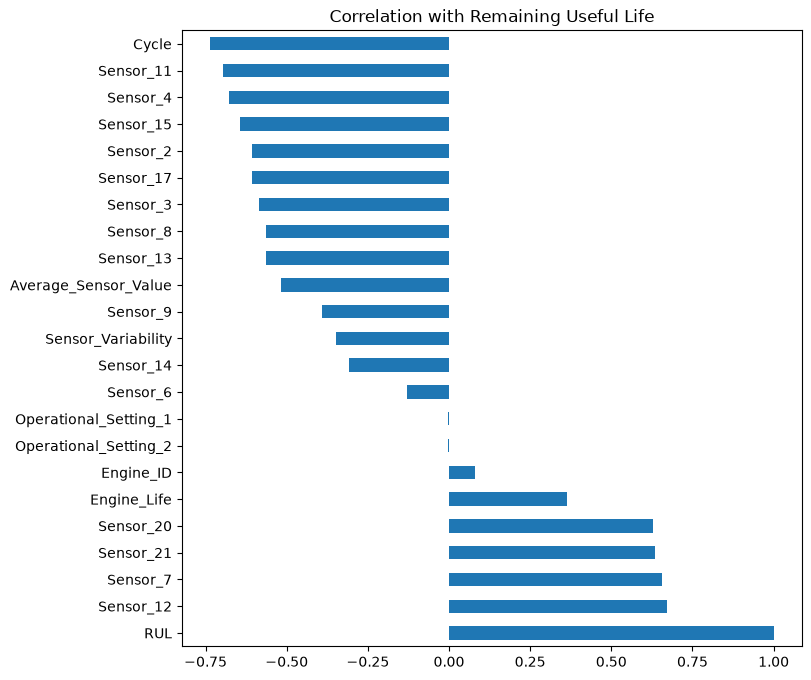

In [7]:
plt.figure(figsize=(8,8))
rul_corr.plot(kind="barh")
plt.title("Correlation with Remaining Useful Life")
plt.show()

### Business Insight

Features with strong positive or negative correlations with Remaining Useful Life are valuable indicators of engine degradation and maintenance planning.

In [8]:
df["RUL"].mean()

np.float64(107.80786195530997)

### Business Insight

The average Remaining Useful Life provides a baseline estimate of engine lifespan within the dataset.

This metric can support long-term maintenance planning.

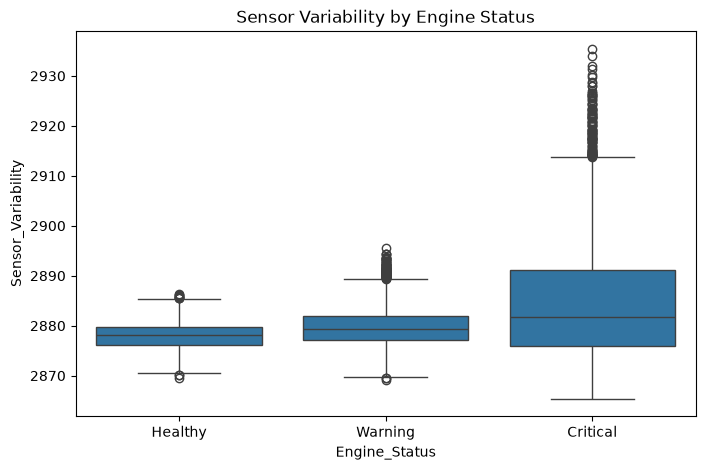

In [9]:
plt.figure(figsize=(8,5))

sns.boxplot(
    x="Engine_Status",
    y="Sensor_Variability",
    data=df
)

plt.title("Sensor Variability by Engine Status")

plt.show()

### Business Insight

Comparing sensor variability across engine health categories helps identify whether unstable sensor behavior is associated with engine degradation.

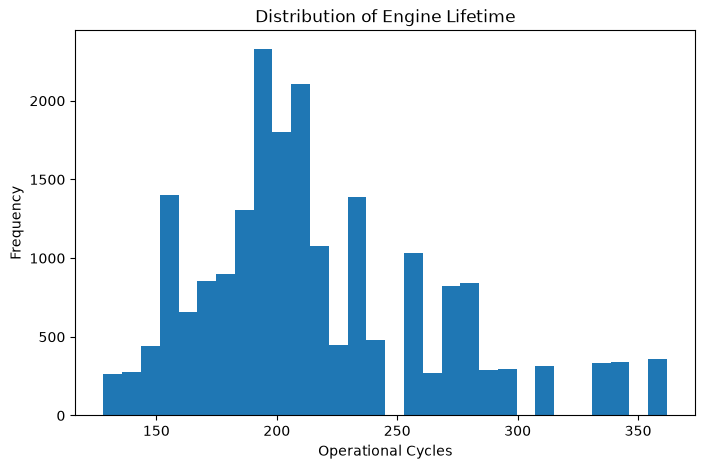

In [10]:
plt.figure(figsize=(8,5))
plt.hist(df["Engine_Life"], bins=30)
plt.title("Distribution of Engine Lifetime")
plt.xlabel("Operational Cycles")
plt.ylabel("Frequency")
plt.show()

### Business Insight

The engine lifetime distribution illustrates differences in operational longevity and supports lifecycle planning.

# Summary

| Analysis               | Finding                         | Business Value                  |
| ---------------------- | ------------------------------- | ------------------------------- |
| Descriptive Statistics | Dataset summarized              | Understand operational behavior |
| Engine Status          | Health categories               | Maintenance prioritization      |
| RUL Correlation        | Important predictors identified | Predictive maintenance          |
| Average RUL            | Lifecycle estimate              | Maintenance planning            |
| Sensor Variability     | Stability comparison            | Operational monitoring          |
| Engine Life            | Lifecycle distribution          | Fleet management                |
